In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/renewable-energy-microgrid-dataset/Renewable_energy_dataset.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# !pip install kagglehub[pandas-datasets]

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("programmer3/renewable-energy-microgrid-dataset")

# print("Path to dataset files:", path)

In [5]:
df=pd.read_csv("/kaggle/input/renewable-energy-microgrid-dataset/Renewable_energy_dataset.csv")

In [6]:
df.head()

,timestamp,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,...,voltage,power_exchange,battery_state_of_charge,battery_charging_rate,battery_discharging_rate,hour_of_day,day_of_week,predicted_solar_pv_output,predicted_wind_power_output,total_predicted_energy
0,2023-01-01 00:00:00,37.454012,8.273684,45.727695,751.423457,18.770285,18.094905,53.215610,1004.872349,294.401249,...,228.933029,-30.551108,10.385097,45.365558,36.183096,0,6,38.977832,8.698819,47.676652
1,2023-01-01 01:00:00,95.071431,48.453800,143.525230,301.682091,6.638605,11.669042,63.906997,1009.493484,185.824084,...,223.617160,-2.023332,86.303649,7.791319,7.240728,1,6,86.059893,53.233701,139.293594
2,2023-01-01 02:00:00,73.199394,30.241951,103.441345,485.378535,14.296742,12.945826,26.234179,970.753014,347.363574,...,222.854681,94.963947,92.269351,41.131011,21.848508,2,6,76.027574,29.339777,105.367351
3,2023-01-01 03:00:00,59.865848,56.340836,116.206685,673.986395,22.357572,38.478603,53.165238,970.833286,193.641771,...,227.861872,52.712924,48.242636,35.145735,14.418611,3,6,65.121215,52.111132,117.232347
4,2023-01-01 04:00:00,15.601864,80.380489,95.982353,868.457364,11.879943,4.807723,69.228330,977.621817,244.023572,...,221.981539,70.347948,42.547153,48.760586,49.343433,4,6,14.599554,81.561628,96.161182


In [7]:
df.iloc[:5, 11:]

,voltage,power_exchange,battery_state_of_charge,battery_charging_rate,battery_discharging_rate,hour_of_day,day_of_week,predicted_solar_pv_output,predicted_wind_power_output,total_predicted_energy
0,228.933029,-30.551108,10.385097,45.365558,36.183096,0,6,38.977832,8.698819,47.676652
1,223.617160,-2.023332,86.303649,7.791319,7.240728,1,6,86.059893,53.233701,139.293594
2,222.854681,94.963947,92.269351,41.131011,21.848508,2,6,76.027574,29.339777,105.367351
3,227.861872,52.712924,48.242636,35.145735,14.418611,3,6,65.121215,52.111132,117.232347
4,221.981539,70.347948,42.547153,48.760586,49.343433,4,6,14.599554,81.561628,96.161182


In [11]:
df.columns

Index(['timestamp', 'solar_pv_output', 'wind_power_output',
       'total_renewable_energy', 'solar_irradiance', 'wind_speed',
       'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand',
       'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge',
       'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day',
       'day_of_week', 'predicted_solar_pv_output',
       'predicted_wind_power_output', 'total_predicted_energy'],
      dtype='object')

In [9]:
import os
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

In [12]:
CSV_PATH = "/kaggle/input/renewable-energy-microgrid-dataset/Renewable_energy_dataset.csv"
DATE_COL = "timestamp"

TARGET_SOLAR = "predicted_solar_pv_output"
TARGET_WIND  = "predicted_wind_power_output"

TEST_SIZE_RATIO = 0.2
RANDOM_SEED = 42

In [13]:
def load_data(path):
    df = pd.read_csv(path, parse_dates=[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return df

df = load_data(CSV_PATH)
print(df.shape)

(3546, 21)


In [14]:
def add_time_features(df):
    # df["hour_of_day"] = df[DATE_COL].dt.hour
    # df["day_of_week"] = df[DATE_COL].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

In [15]:
def create_solar_features(df):
    df = add_time_features(df)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"solar_pv_output_lag_{lag}"] = df["solar_pv_output"].shift(lag)

    df = df.ffill().bfill().fillna(0.0)
    return df

In [16]:
def create_wind_features(df):
    df = add_time_features(df)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"wind_power_output_lag_{lag}"] = df["wind_power_output"].shift(lag)

    df = df.ffill().bfill().fillna(0.0)
    return df

In [18]:
SOLAR_FEATURES = [
    "solar_irradiance", "temperature", "humidity",
    "grid_load_demand", "frequency", "voltage",
    "battery_state_of_charge",
    "hour_of_day", "day_of_week", "hour_sin", "hour_cos"
] + [f"solar_pv_output_lag_{l}" for l in [1,2,3,6,12,24]]

In [19]:
WIND_FEATURES = [
    "wind_speed", "temperature", "atmospheric_pressure",
    "grid_load_demand", "frequency", "voltage",
    "battery_state_of_charge",
    "hour_of_day", "day_of_week", "hour_sin", "hour_cos"
] + [f"wind_power_output_lag_{l}" for l in [1,2,3,6,12,24]]


In [20]:
split_idx = int(len(df) * (1 - TEST_SIZE_RATIO))
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

In [21]:
solar_train = create_solar_features(train_df.copy())
solar_test  = create_solar_features(test_df.copy())

X_train_solar = solar_train[SOLAR_FEATURES]
y_train_solar = solar_train[TARGET_SOLAR]

X_test_solar = solar_test[SOLAR_FEATURES]
y_test_solar = solar_test[TARGET_SOLAR]


In [22]:
wind_train = create_wind_features(train_df.copy())
wind_test  = create_wind_features(test_df.copy())

X_train_wind = wind_train[WIND_FEATURES]
y_train_wind = wind_train[TARGET_WIND]

X_test_wind = wind_test[WIND_FEATURES]
y_test_wind = wind_test[TARGET_WIND]


In [23]:
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial, X, y):
    params = {
        "objective": "regression",
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "num_leaves": trial.suggest_int("num_leaves", 32, 256),
        "max_depth": trial.suggest_int("max_depth", 4, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.9),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.9),
        "bagging_freq": 1,
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "random_state": RANDOM_SEED
    }

    maes = []
    for train_idx, val_idx in tscv.split(X):
        model = lgb.LGBMRegressor(**params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[val_idx])
        maes.append(mean_absolute_error(y.iloc[val_idx], preds))

    return np.mean(maes)


In [ ]:
import optuna
import lightgbm as lgb
study_solar = optuna.create_study(direction="minimize")
study_solar.optimize(lambda t: objective(t, X_train_solar, y_train_solar), n_trials=50)

solar_model = lgb.LGBMRegressor(**study_solar.best_params)
solar_model.fit(X_train_solar, y_train_solar)


[I 2025-12-13 14:19:24,570] A new study created in memory with name: no-name-63d4b7a1-6c71-47cc-9b06-d27797ad902a


In [ ]:
study_wind = optuna.create_study(direction="minimize")
study_wind.optimize(lambda t: objective(t, X_train_wind, y_train_wind), n_trials=50)

wind_model = lgb.LGBMRegressor(**study_wind.best_params)
wind_model.fit(X_train_wind, y_train_wind)


In [30]:
solar_pred = solar_model.predict(X_test_solar)
wind_pred  = wind_model.predict(X_test_wind)

total_pred = solar_pred + wind_pred
total_true = test_df["total_predicted_energy"].values

print("Solar MAE:", mean_absolute_error(y_test_solar, solar_pred))
print("Wind MAE:", mean_absolute_error(y_test_wind, wind_pred))
print("Total MAE:", mean_absolute_error(total_true, total_pred))


[LightGBM] [Warning] feature_fraction is set=0.8738633713119157, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8738633713119157
[LightGBM] [Warning] bagging_fraction is set=0.6040409472998648, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6040409472998648
[LightGBM] [Warning] feature_fraction is set=0.6608665640067029, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6608665640067029
[LightGBM] [Warning] bagging_fraction is set=0.8224521921743061, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8224521921743061
Solar MAE: 25.29127333612325
Wind MAE: 25.299323948833194
Total MAE: 34.473915806236626


In [12]:
def add_lags_and_rolls(df, col, lags, rolls):
    for lag in range(1, lags+1):
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    for w in rolls:
        df[f"{col}_roll_mean_{w}"] = df[col].shift(1).rolling(window=w, min_periods=1).mean()
        df[f"{col}_roll_std_{w}"] = df[col].shift(1).rolling(window=w, min_periods=1).std().fillna(0.0)
    return df


In [14]:
df = add_lags_and_rolls(
    df.copy(),
    col="solar_pv_output",
    lags=24,          # creates lag_1 ... lag_24
    rolls=[6, 24]
)

df = add_lags_and_rolls(
    df.copy(),
    col="wind_power_output",
    lags=24,
    rolls=[6, 24]
)

In [15]:
df

,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,frequency,...,wind_power_output_lag_19,wind_power_output_lag_20,wind_power_output_lag_21,wind_power_output_lag_22,wind_power_output_lag_23,wind_power_output_lag_24,wind_power_output_roll_mean_6,wind_power_output_roll_std_6,wind_power_output_roll_mean_24,wind_power_output_roll_std_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,37.454012,8.273684,45.727695,751.423457,18.770285,18.094905,53.215610,1004.872349,294.401249,49.123760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
2023-01-01 01:00:00,95.071431,48.453800,143.525230,301.682091,6.638605,11.669042,63.906997,1009.493484,185.824084,49.908870,...,NaN,NaN,NaN,NaN,NaN,NaN,8.273684,0.000000,8.273684,0.000000
2023-01-01 02:00:00,73.199394,30.241951,103.441345,485.378535,14.296742,12.945826,26.234179,970.753014,347.363574,49.575119,...,NaN,NaN,NaN,NaN,NaN,NaN,28.363742,28.411632,28.363742,28.411632
2023-01-01 03:00:00,59.865848,56.340836,116.206685,673.986395,22.357572,38.478603,53.165238,970.833286,193.641771,49.549129,...,NaN,NaN,NaN,NaN,NaN,NaN,28.989811,20.119302,28.989811,20.119302
2023-01-01 04:00:00,15.601864,80.380489,95.982353,868.457364,11.879943,4.807723,69.228330,977.621817,244.023572,49.444763,...,NaN,NaN,NaN,NaN,NaN,NaN,35.827568,21.374686,35.827568,21.374686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-28 13:00:00,80.902364,61.858515,142.760879,494.648306,6.446750,36.541852,26.858676,977.291885,153.758775,49.535134,...,15.484268,49.756608,3.429790,60.095719,13.101462,77.851588,50.041882,26.558537,43.358444,24.123425
2023-05-28 14:00:00,14.692192,30.984712,45.676904,491.221975,2.355559,-1.724013,67.040938,997.545635,52.662892,50.783171,...,18.292293,15.484268,49.756608,3.429790,60.095719,13.101462,47.599858,24.207583,42.692066,23.337253
2023-05-28 15:00:00,34.264515,8.579428,42.843943,967.551677,7.879682,-2.787434,63.139355,990.829339,319.497642,50.691234,...,36.504757,18.292293,15.484268,49.756608,3.429790,60.095719,45.551192,25.148465,43.437201,22.626036


In [17]:
df = df.dropna().reset_index(drop=True)

In [18]:
df

,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,frequency,...,wind_power_output_lag_19,wind_power_output_lag_20,wind_power_output_lag_21,wind_power_output_lag_22,wind_power_output_lag_23,wind_power_output_lag_24,wind_power_output_roll_mean_6,wind_power_output_roll_std_6,wind_power_output_roll_mean_24,wind_power_output_roll_std_24
0,45.606998,31.387550,76.994548,843.499531,22.051205,36.300371,20.598759,1000.374370,436.035194,50.761418,...,13.714849,80.380489,56.340836,30.241951,48.453800,8.273684,67.736495,14.493561,46.667886,24.925042
1,78.517596,53.802271,132.319867,252.663875,11.109845,-8.809698,39.725831,1031.451288,62.293780,49.591981,...,58.069908,13.714849,80.380489,56.340836,30.241951,48.453800,65.327229,19.273900,47.630964,23.798101
2,19.967378,84.010808,103.978186,754.058240,14.723591,-7.422256,75.238346,1031.928504,51.461568,49.172749,...,50.550876,58.069908,13.714849,80.380489,56.340836,30.241951,62.210840,19.393360,47.853817,23.831161
3,51.423444,98.945113,150.368557,657.518018,3.479695,37.937165,65.080351,1029.831313,176.566681,49.173975,...,14.407879,50.550876,58.069908,13.714849,80.380489,56.340836,66.641181,21.048111,50.094186,24.617902
4,59.241457,88.951931,148.193388,925.970541,0.084696,3.858031,20.780054,960.112484,461.300017,50.112037,...,62.399849,14.407879,50.550876,58.069908,13.714849,80.380489,72.011828,24.841857,51.869364,26.548321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3517,80.902364,61.858515,142.760879,494.648306,6.446750,36.541852,26.858676,977.291885,153.758775,49.535134,...,15.484268,49.756608,3.429790,60.095719,13.101462,77.851588,50.041882,26.558537,43.358444,24.123425
3518,14.692192,30.984712,45.676904,491.221975,2.355559,-1.724013,67.040938,997.545635,52.662892,50.783171,...,18.292293,15.484268,49.756608,3.429790,60.095719,13.101462,47.599858,24.207583,42.692066,23.337253
3519,34.264515,8.579428,42.843943,967.551677,7.879682,-2.787434,63.139355,990.829339,319.497642,50.691234,...,36.504757,18.292293,15.484268,49.756608,3.429790,60.095719,45.551192,25.148465,43.437201,22.626036
3520,86.465892,9.093545,95.559437,555.155968,21.879680,17.071470,68.673975,985.361803,278.530184,49.805981,...,43.243717,36.504757,18.292293,15.484268,49.756608,3.429790,38.911355,29.176676,41.290689,23.407115


### **SOLAR_MODEL**

In [19]:
df.columns

Index(['solar_pv_output', 'wind_power_output', 'total_renewable_energy',
       'solar_irradiance', 'wind_speed', 'temperature', 'humidity',
       'atmospheric_pressure', 'grid_load_demand', 'frequency', 'voltage',
       'power_exchange', 'battery_state_of_charge', 'battery_charging_rate',
       'battery_discharging_rate', 'hour_of_day', 'day_of_week',
       'predicted_solar_pv_output', 'predicted_wind_power_output',
       'total_predicted_energy', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'solar_pv_output_lag_1', 'solar_pv_output_lag_2',
       'solar_pv_output_lag_3', 'solar_pv_output_lag_4',
       'solar_pv_output_lag_5', 'solar_pv_output_lag_6',
       'solar_pv_output_lag_7', 'solar_pv_output_lag_8',
       'solar_pv_output_lag_9', 'solar_pv_output_lag_10',
       'solar_pv_output_lag_11', 'solar_pv_output_lag_12',
       'solar_pv_output_lag_13', 'solar_pv_output_lag_14',
       'solar_pv_output_lag_15', 'solar_pv_output_lag_16',
       'solar_pv_output_lag_17', 

In [23]:
solar_features = ['solar_irradiance', 'temperature', 'humidity',
       'atmospheric_pressure', 'grid_load_demand', 'frequency', 'voltage',
       'power_exchange', 'battery_state_of_charge', 'battery_charging_rate',
       'battery_discharging_rate', 'hour_of_day', 'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'solar_pv_output_lag_1', 'solar_pv_output_lag_2',
       'solar_pv_output_lag_3', 'solar_pv_output_lag_4',
       'solar_pv_output_lag_5', 'solar_pv_output_lag_6',
       'solar_pv_output_lag_7', 'solar_pv_output_lag_8',
       'solar_pv_output_lag_9', 'solar_pv_output_lag_10',
       'solar_pv_output_lag_11', 'solar_pv_output_lag_12',
       'solar_pv_output_lag_13', 'solar_pv_output_lag_14',
       'solar_pv_output_lag_15', 'solar_pv_output_lag_16',
       'solar_pv_output_lag_17', 'solar_pv_output_lag_18',
       'solar_pv_output_lag_19', 'solar_pv_output_lag_20',
       'solar_pv_output_lag_21', 'solar_pv_output_lag_22',
       'solar_pv_output_lag_23', 'solar_pv_output_lag_24',
       'solar_pv_output_roll_mean_6', 'solar_pv_output_roll_std_6',
       'solar_pv_output_roll_mean_24', 'solar_pv_output_roll_std_24',
       ]

X_solar = df[solar_features]
y_solar = df['solar_pv_output']


In [27]:
split_date = '2023-01-01'

X_solar_train = X_solar.loc[:split_date]
X_solar_test  = X_solar.loc[split_date:]

y_solar_train = y_solar.loc[:split_date]
y_solar_test  = y_solar.loc[split_date:]


In [ ]:
X_solar_train.shape,X_solar_test.shape,y_solar_train.shape,y_solar_test.shape

In [41]:
solar_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

solar_model.fit(X_solar_train, y_solar_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [42]:
solar_pred = solar_model.predict(X_solar_test)

print("Solar MSE:", mean_squared_error(y_solar_test, solar_pred))
print("Solar MAE:", mean_absolute_error(y_solar_test, solar_pred))
print("Solar RMSE:", np.sqrt(mean_squared_error(y_solar_test, solar_pred)))


Solar MSE: 899.909669989549
Solar MAE: 25.618160207246678
Solar RMSE: 29.99849446204841


In [8]:
CSV_PATH = "/kaggle/input/renewable-energy-microgrid-dataset/Renewable_energy_dataset.csv"
DATE_COL = "timestamp"
TARGET_SOLAR = "predicted_solar_pv_output"
TARGET_WIND = "predicted_wind_power_output"
TEST_SIZE_RATIO = 0.25            # final hold-out fraction
LAG_HORIZON = 24                  # how many past hours to use as lags
ROLL_WINDOWS = [3, 6, 12]         # rolling windows in hours
RANDOM_SEED = 42
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [35]:
# def create_features(df):
#     df = add_time_features(df)
#     # Columns to create lags/rolls for (observed series)
#     to_lag = [
#         "solar_pv_output", "wind_power_output", "total_renewable_energy",
#         "solar_irradiance", "wind_speed", "grid_load_demand", "frequency"
#     ]
#     for col in to_lag:
#         if col in df.columns:
#             df = add_lags_and_rolls(df, col, LAG_HORIZON, ROLL_WINDOWS)
#     # Fill any remaining NaNs produced by shift with a simple forward/backfill
#     df.fillna(method="ffill", inplace=True)
#     df.fillna(method="bfill", inplace=True)
#     # If still NaN (e.g., at head), fill with zeros
#     df.fillna(0.0, inplace=True)
#     return df


# def create_features(df):
#     df = add_time_features(df)

#     to_lag = [
#         "solar_pv_output", "wind_power_output", "total_renewable_energy",
#         "solar_irradiance", "wind_speed", "grid_load_demand", "frequency"
#     ]

#     # -- Normalize lag horizon into a list --
#     if isinstance(LAG_HORIZON, int):
#         # Option A: generate all lags 1..N
#         lag_list = list(range(1, LAG_HORIZON + 1))
#         # Option B (if you only want a single lag!): lag_list = [LAG_HORIZON]
#     else:
#         lag_list = list(LAG_HORIZON)

#     # -- Normalize rolling windows --
#     if isinstance(ROLL_WINDOWS, int):
#         roll_list = [ROLL_WINDOWS]
#     else:
#         roll_list = list(ROLL_WINDOWS)

#     # Collect new features in a dict
#     new_feature_dict = {}

#     for col in to_lag:
#         if col not in df.columns:
#             continue

#         col_series = df[col]

#         # --- Lags ---
#         for lag in lag_list:
#             new_feature_dict[f"{col}_lag_{lag}"] = col_series.shift(lag)

#         # --- Rolling stats ---
#         for win in roll_list:
#             rolled = col_series.rolling(window=win)
#             new_feature_dict[f"{col}_roll_mean_{win}"] = rolled.mean()
#             new_feature_dict[f"{col}_roll_std_{win}"]  = rolled.std()

#     # Add all new features at once (prevents fragmentation)
#     if new_feature_dict:
#         df = pd.concat([df, pd.DataFrame(new_feature_dict, index=df.index)], axis=1)

#     # Clean NaNs
#     df = df.ffill().bfill().fillna(0.0)

#     return df


In [36]:
BASE_FEATURES = [
    "solar_irradiance", "wind_speed", "temperature",
    "humidity", "atmospheric_pressure",
    "grid_load_demand", "frequency", "voltage",
    "battery_state_of_charge",
    "battery_charging_rate", "battery_discharging_rate",
    "hour_of_day", "day_of_week",
    "hour_sin", "hour_cos"
]

def create_features(df, target_col):
    df = add_time_features(df)

    lag_source = target_col.replace("predicted_", "").replace("_output", "_output")

    lag_features = {}
    for lag in [1, 2, 3, 6, 12, 24]:
        lag_features[f"{lag_source}_lag_{lag}"] = df[lag_source].shift(lag)

    df = pd.concat([df, pd.DataFrame(lag_features, index=df.index)], axis=1)
    df = df.ffill().bfill().fillna(0.0)
    return df


In [37]:
def train_lightgbm(X_train, y_train, X_val, y_val, objective="regression", params=None):
    # Default params
    if params is None:
        params = {
            "objective": objective,
            "learning_rate": 0.03,
            "num_leaves": 128,
            "max_depth": -1,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "n_estimators": 500,      # FIXED number of trees
            "random_state": RANDOM_SEED
        }

    # Create model
    model = lgb.LGBMRegressor(**params)

    # Train WITHOUT early stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        # verbose=50         # this works on all versions
    )

    return model


In [38]:
# def evaluate_model(model, X, y_true, name="model"):
#     y_pred = model.predict(X, num_iteration=model.best_iteration)
#     mae = mean_absolute_error(y_true, y_pred)
#     rmse = math.sqrt(mean_squared_error(y_true, y_pred))
#     return {"mae": mae, "rmse": rmse, "y_pred": y_pred}

def evaluate_model(model, X, y_true, name="model"):
    # Use best_iteration_ if it exists, else None
    best_iter = getattr(model, "best_iteration_", None)

    if best_iter is not None:
        y_pred = model.predict(X, num_iteration=best_iter)
    else:
        y_pred = model.predict(X)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return {"mae": mae, "rmse": rmse, "y_pred": y_pred}


In [39]:
print("Loading data...")
df = load_data(CSV_PATH)
print("Rows:", len(df))

Loading data...
Rows: 3546


In [41]:
print("Creating features...")
# df_feat = create_features(df.copy())

df_feat_solar = create_features(
    df.copy(),
    target_col="predicted_solar_pv_output"
)

Creating features...


In [42]:
df_feat_wind = create_features(
    df.copy(),
    target_col="predicted_wind_power_output"
)


In [ ]:
df_feat_wind

In [46]:
# drop columns not used as features
non_feature_cols = [DATE_COL, TARGET_SOLAR, TARGET_WIND, "total_predicted_energy"]
feature_cols_wind = [c for c in df_feat_wind.columns if c not in non_feature_cols]
feature_cols_solar = [c for c in df_feat_solar.columns if c not in non_feature_cols]

In [61]:
n = len(df_feat)
test_start = int(n * (1 - TEST_SIZE_RATIO))
train_df = df_feat.iloc[:test_start].copy()
test_df = df_feat.iloc[test_start:].copy()

In [63]:
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train_solar = train_df[TARGET_SOLAR]
y_test_solar = test_df[TARGET_SOLAR]
y_train_wind = train_df[TARGET_WIND]
y_test_wind = test_df[TARGET_WIND]

In [64]:
# further split training into train/val for early stopping
X_tr, X_val, y_tr_solar, y_val_solar = train_test_split(
    X_train, y_train_solar, test_size=0.15, shuffle=False
)
_, _, y_tr_wind, y_val_wind = train_test_split(
    X_train, y_train_wind, test_size=0.15, shuffle=False
)

In [ ]:
# -------------------
# Train solar model
# -------------------
print("Training solar model...")
solar_model = train_lightgbm(X_tr, y_tr_solar, X_val, y_val_solar, objective="regression")

In [ ]:
print("Training wind model...")
wind_model = train_lightgbm(X_tr, y_tr_wind, X_val, y_val_wind, objective="regression")

In [70]:
print("Evaluating on test set...")
solar_eval = evaluate_model(solar_model, X_test, y_test_solar, name="solar")
wind_eval = evaluate_model(wind_model, X_test, y_test_wind, name="wind")

print("Solar MAE:", solar_eval["mae"], "RMSE:", solar_eval["rmse"])
print("Wind  MAE:", wind_eval["mae"], "RMSE:", wind_eval["rmse"])

Evaluating on test set...
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Solar MAE: 2.643171568707618 RMSE: 3.5666468607778765
Wind  MAE: 2.7173419711221203 RMSE: 3.632803356016376


In [73]:
# Compose total predicted energy as sum of solar + wind predictions
total_pred_test = solar_eval["y_pred"] + wind_eval["y_pred"]
total_true_test = test_df["total_predicted_energy"].values if "total_predicted_energy" in test_df.columns else (test_df["solar_pv_output"].values + test_df["wind_power_output"].values)
total_mae = mean_absolute_error(total_true_test, total_pred_test)
total_rmse = math.sqrt(mean_squared_error(total_true_test, total_pred_test))
print("Total predicted energy MAE:", total_mae, "RMSE:", total_rmse)

Total predicted energy MAE: 4.082479774138156 RMSE: 5.267935160636811


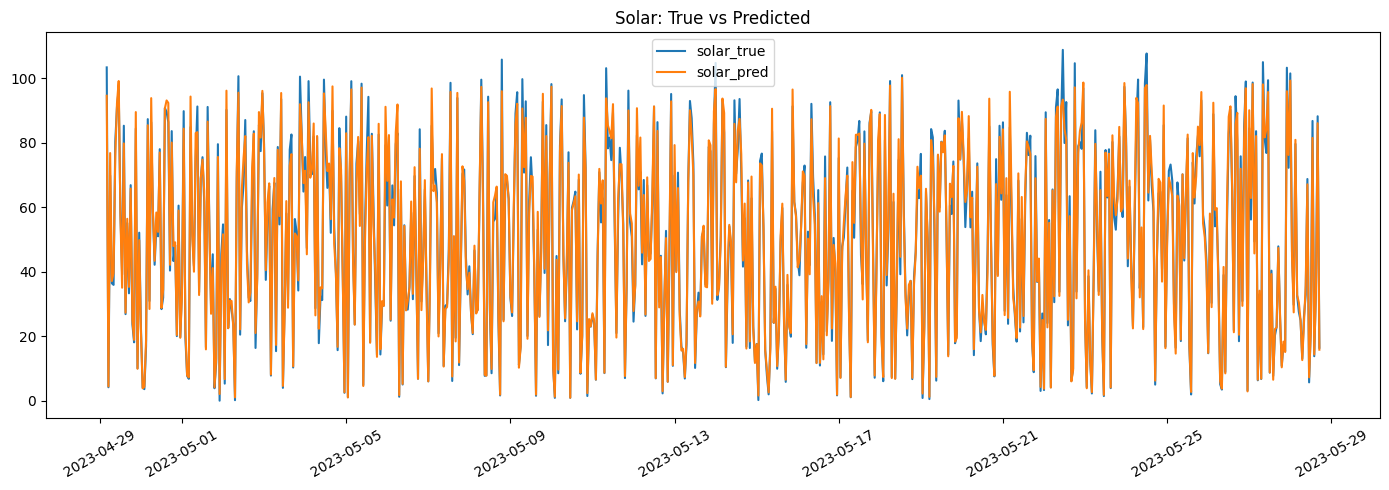

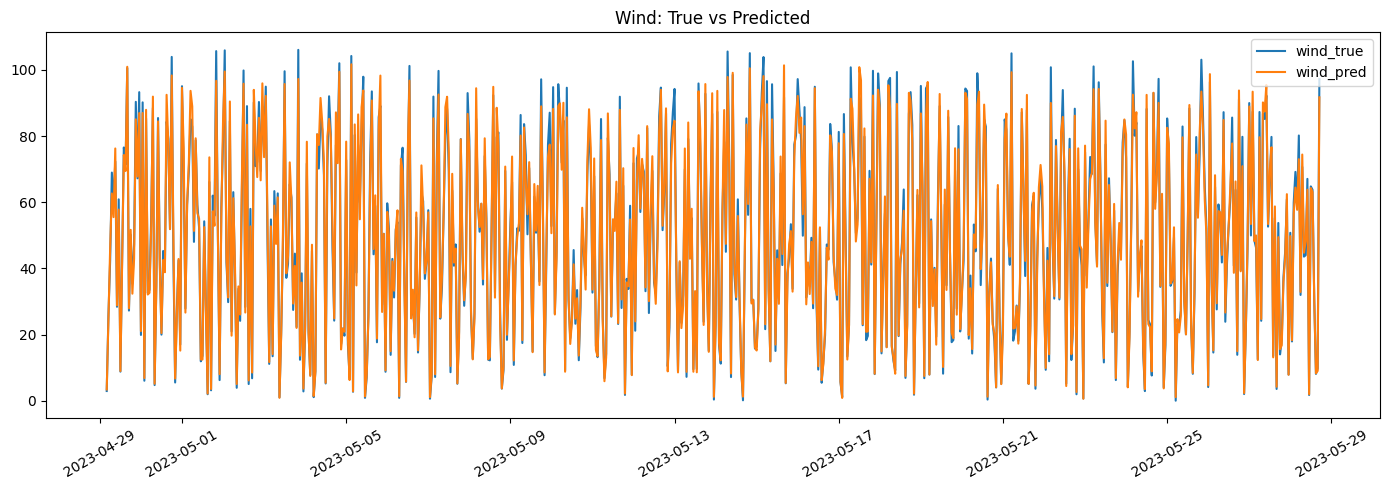

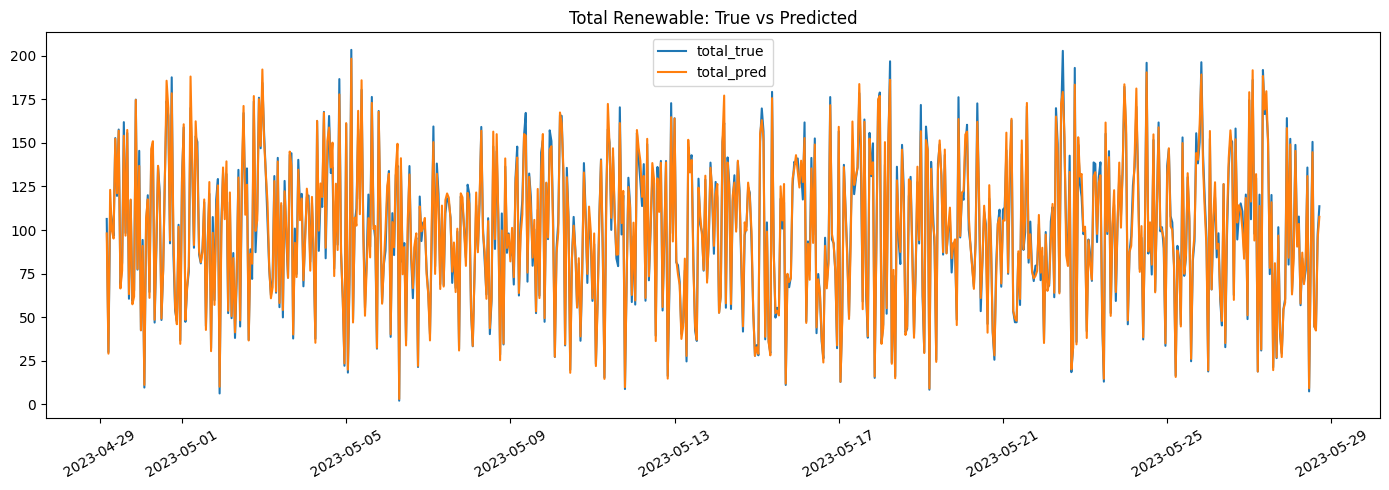

In [74]:
try:
    idx = test_df.index
    time_index = test_df[DATE_COL]

    plt.figure(figsize=(14, 5))
    plt.plot(time_index, y_test_solar.values, label="solar_true")
    plt.plot(time_index, solar_eval["y_pred"], label="solar_pred")
    plt.title("Solar: True vs Predicted")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(time_index, y_test_wind.values, label="wind_true")
    plt.plot(time_index, wind_eval["y_pred"], label="wind_pred")
    plt.title("Wind: True vs Predicted")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(time_index, total_true_test, label="total_true")
    plt.plot(time_index, total_pred_test, label="total_pred")
    plt.title("Total Renewable: True vs Predicted")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plotting failed:", e)

In [77]:
def predict_on_rows(df_rows):
    df_temp = df_rows.copy()
    df_temp = create_features(df_temp)  # this will create lags/rolls assuming history present
    features_now = [c for c in df_temp.columns if c not in non_feature_cols]
    # take last row as current time
    X_now = df_temp.iloc[[-1]][feature_cols]
    s = solar_model.predict(X_now)
    w = wind_model.predict(X_now)
    return float(s[0]), float(w[0]), float(s[0] + w[0])

In [78]:
latest_rows = df.tail(LAG_HORIZON + 5)   # 24 lags + few extra
solar_pred, wind_pred, total_pred = predict_on_rows(latest_rows)

print("Predicted Solar:", solar_pred)
print("Predicted Wind:", wind_pred)
print("Predicted Total Renewable:", total_pred)


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Predicted Solar: 15.823747912219773
Predicted Wind: 91.73089211283158
Predicted Total Renewable: 107.55464002505136


In [79]:
# 2. Use last 30 rows to have enough historical data
history_window = df.tail(30)

# 3. Predict next hour
solar_pred, wind_pred, total_pred = predict_on_rows(history_window)

print("Solar Forecast:", solar_pred)
print("Wind Forecast:", wind_pred)
print("Total Renewable Forecast:", total_pred)


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Solar Forecast: 15.823747912219773
Wind Forecast: 91.73089211283158
Total Renewable Forecast: 107.55464002505136


In [81]:
df.tail()

,timestamp,solar_pv_output,wind_power_output,total_renewable_energy,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand,...,voltage,power_exchange,battery_state_of_charge,battery_charging_rate,battery_discharging_rate,hour_of_day,day_of_week,predicted_solar_pv_output,predicted_wind_power_output,total_predicted_energy
3541,2023-05-28 13:00:00,80.902364,61.858515,142.760879,494.648306,6.446750,36.541852,26.858676,977.291885,153.758775,...,223.105336,-73.803501,51.215748,43.885726,32.716094,13,6,86.784572,63.783080,150.567652
3542,2023-05-28 14:00:00,14.692192,30.984712,45.676904,491.221975,2.355559,-1.724013,67.040938,997.545635,52.662892,...,232.468998,85.987441,25.446349,28.393457,33.363658,14,6,13.793963,30.879954,44.673917
3543,2023-05-28 15:00:00,34.264515,8.579428,42.843943,967.551677,7.879682,-2.787434,63.139355,990.829339,319.497642,...,231.724660,-81.043898,45.494616,24.197498,13.027391,15,6,34.907322,8.126541,43.033863
3544,2023-05-28 16:00:00,86.465892,9.093545,95.559437,555.155968,21.879680,17.071470,68.673975,985.361803,278.530184,...,226.760244,-99.184079,29.295291,23.253830,1.761445,16,6,88.241886,9.785328,98.027215
3545,2023-05-28 17:00:00,15.492531,92.322375,107.814906,804.075174,8.679171,20.721683,12.347496,960.278558,264.942670,...,225.917873,-22.193902,93.402338,46.791323,33.267658,17,6,16.432718,97.206881,113.639599
